# ACTUWISE - Module 2 : Provisionnement des Reserves Techniques
## Partie 2 - Machine Learning Reserving (XGBoost sur Triangles)

---

**Auteur :** [Prenom Nom] - Stage Actuariat  
**Module :** Module 2 - Provisionnement  
**Partie :** 2 - Machine Learning Reserving  
**Pre-requis :** Avoir execute la Partie 1 (resultats Chain-Ladder, BF, Cape Cod disponibles)

---

### Objectif

La Partie 1 a calcule les reserves par methodes actuarielles classiques.  
La Partie 2 enrichit ces estimations avec un modele XGBoost entraine directement sur le triangle.

**Principe :** Transformer chaque case connue du triangle en une ligne de tableau ML, puis apprendre les patterns de developpement pour predire les cases manquantes.

### References academiques

- Gabrielli, A. & Wuthrich, M.V. (2018). *An Individual Claims History Simulation Machine*. SSRN 3120720.
- Kuo, K. (2020). *DeepTriangle: A Deep Learning Approach to Loss Reserving*. Risks, 8(4), 97.
- Friedman, J. (2001). *Greedy Function Approximation: A Gradient Boosting Machine*. Annals of Statistics.
- England, P.D. & Verrall, R.J. (2002). *Stochastic claims reserving in general insurance*. British Actuarial Journal.
- Package reference : https://github.com/casact/chainladder-python

---

### Structure

```
0. Imports et configuration
1. Rechargement des donnees + resultats Partie 1
2. Transformation du triangle en tableau ML
3. Feature Engineering
4. Validation temporelle (out-of-time)
5. Modele XGBoost - entrainement et prediction
6. Intervalles de confiance par Bootstrap
7. SHAP - explicabilite des predictions
8. Benchmark XGBoost vs Chain-Ladder vs BF
9. Synthese et recommandation finale
```


## 0. Imports et Configuration

In [4]:
pip install xgboost shap --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

C1 = '#1a3c6e'
C2 = '#1a7a6a'
C3 = '#c0392b'
C4 = '#e67e22'
C5 = '#8e44ad'
RANDOM_STATE = 42

print("Imports reussis")
print("XGBoost version :", xgb.__version__)

Imports reussis
XGBoost version : 3.3.0


---
## 1. Rechargement des donnees et resultats Partie 1

On recharge les donnees brutes et on recalcule les resultats de la Partie 1  
pour les utiliser comme features et comme reference de benchmark.


In [6]:
# Chargement donnees
df_sin  = pd.read_excel('SAP_AUTO_PAR_GARANTIES_AU_31122023_-_MAJ.xls', engine='xlrd')
df_prod = pd.read_excel('Base_production_sur_6_ans.xlsx')

# Colonnes cles
reg_cols  = sorted([c for c in df_sin.columns if c.startswith('REG_AMOUNT_')],
                    key=lambda x: int(x.split('_')[-1]))
sap_cols  = sorted([c for c in df_sin.columns if c.startswith('SAP_')],
                    key=lambda x: int(x.split('_')[-1]))
pa_cols   = sorted([c for c in df_prod.columns if c.startswith('PA ')],
                    key=lambda x: int(x.split()[-1]))
reg_focus = [c for c in reg_cols if int(c.split('_')[-1]) >= 2018]
ANNEES    = list(range(2018, 2024))
N         = len(ANNEES)

# Preprocessing
df_sin['annee_survenance'] = df_sin['TMP_CLMLOSS_DATE'].dt.year
for col in reg_cols:
    df_sin[col] = df_sin[col].abs()

primes        = {int(col.split()[-1]): df_prod[col].sum() for col in pa_cols}
sap_par_annee = {a: df_sin[df_sin['annee_survenance'] == a]['SAP_2023'].sum() for a in ANNEES}

# Infos sinistres par annee (features supplementaires)
infos_annee = {}
for annee in ANNEES:
    df_a = df_sin[df_sin['annee_survenance'] == annee]
    infos_annee[annee] = {
        'nb_sinistres':        len(df_a),
        'pct_corporels':       (df_a['TMP_TYPE'] == 'C').mean() * 100,
        'delai_decl_moyen':    (df_a['CLM_REPORTED_DATE'] - df_a['TMP_CLMLOSS_DATE']).dt.days.clip(lower=0).mean(),
        'pct_ouverts':         (df_a['SAP_2023'] > 0).mean() * 100,
        'sap_total':           df_a['SAP_2023'].sum(),
        'prime':               primes.get(annee, 0),
    }

df_infos = pd.DataFrame(infos_annee).T
df_infos.index.name = 'annee_survenance'

print("Infos sinistres par annee :")
display(df_infos.round(2))

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
Infos sinistres par annee :


,nb_sinistres,pct_corporels,delai_decl_moyen,pct_ouverts,sap_total,prime
annee_survenance,,,,,,
2018,4278.0,5.12,21.57,4.63,526075.75,11123391.34
2019,4156.0,5.20,20.90,4.72,604874.83,11539431.25
2020,3586.0,6.02,21.14,13.52,1216724.62,12824242.84
2021,4179.0,4.79,18.93,19.22,2479054.30,15346393.03
2022,4740.0,4.49,13.30,26.86,4050535.97,17674303.33
2023,4792.0,3.01,7.28,52.44,6766834.37,19475873.99


In [7]:
# Reconstruction triangle cumule (identique Partie 1)
triangle_inc = {}
for annee_surv in ANNEES:
    df_as = df_sin[df_sin['annee_survenance'] == annee_surv]
    row   = {}
    for col in reg_focus:
        annee_cal = int(col.split('_')[-1])
        dev       = annee_cal - annee_surv + 1
        if annee_cal >= annee_surv:
            row[dev] = df_as[col].sum()
    triangle_inc[annee_surv] = row

tri_inc   = pd.DataFrame(triangle_inc).T.fillna(0)
tri_cumul = tri_inc.cumsum(axis=1).astype(float)
devs      = list(tri_cumul.columns)

for i, annee_surv in enumerate(ANNEES):
    dev_max = N - i
    for j, dev in enumerate(devs):
        if dev > dev_max:
            tri_cumul.loc[annee_surv, dev] = np.nan

# Facteurs Chain-Ladder (reference Partie 1)
facteurs_cl = {}
for j in range(len(devs) - 1):
    dj  = devs[j]
    dj1 = devs[j + 1]
    cj  = tri_cumul[dj].dropna()
    cj1 = tri_cumul[dj1].dropna()
    idx = cj.index.intersection(cj1.index)
    if len(idx) > 0 and cj[idx].sum() > 0:
        facteurs_cl[(dj, dj1)] = cj1[idx].sum() / cj[idx].sum()

facteurs_list = list(facteurs_cl.values())

print("Triangle cumule reconstruit :")
display(tri_cumul.round(0))
print(f"\nFacteurs CL : {[round(f, 4) for f in facteurs_list]}")

Triangle cumule reconstruit :


,1,2,3,4,5,6
2018,2199765.0,3951727.0,4689648.0,5086513.0,5358377.0,5545551.0
2019,2075632.0,3993845.0,4717602.0,5065568.0,5346432.0,NaN
2020,2107584.0,4280970.0,5016023.0,5331244.0,NaN,NaN
2021,2077306.0,4899350.0,5731455.0,NaN,NaN,NaN
2022,2907693.0,6011303.0,NaN,NaN,NaN,NaN
2023,3637932.0,NaN,NaN,NaN,NaN,NaN



Facteurs CL : [np.float64(2.0353), np.float64(1.1769), np.float64(1.0735), np.float64(1.0544), np.float64(1.0349)]


---
## 2. Transformation du Triangle en Tableau ML

### Principe (Gabrielli & Wuthrich, 2018)

Chaque **transition connue** du triangle devient une ligne d'entrainement :
- (annee survenance i, dev j) → (annee survenance i, dev j+1)

Le triangle 6x6 contient **21 cases connues** et **15 transitions** utilisables pour l'entrainement.

La variable cible est **C(i, j+1)** — le montant cumule a la prochaine annee de developpement.


In [8]:
# Transformation triangle -> tableau ML
rows = []

for i, annee_surv in enumerate(ANNEES):
    dev_max = N - i   # nb de developpements disponibles pour cette annee

    for k, dev in enumerate(devs[:-1]):
        dev_next = devs[k + 1]

        # On a besoin des deux cases consecutives connues
        c_actuel = tri_cumul.loc[annee_surv, dev]
        c_suivant = tri_cumul.loc[annee_surv, dev_next]

        if pd.isna(c_actuel) or pd.isna(c_suivant):
            continue  # case non connue, on ignore

        c_precedent = tri_cumul.loc[annee_surv, devs[k-1]] if k > 0 else 0
        facteur_obs = c_actuel / c_precedent if (c_precedent and c_precedent > 0) else 0

        # Infos sinistres de l'annee
        info = infos_annee[annee_surv]

        row = {
            # Position dans le triangle
            'annee_survenance':    annee_surv,
            'dev_actuel':          dev,
            'dev_suivant':         dev_next,
            'dev_restant':         len(devs) - 1 - k,
            'anciennete':          2023 - annee_surv,

            # Valeurs du triangle
            'C_cumul_actuel':      c_actuel,
            'C_precedent':         c_precedent,
            'facteur_obs':         facteur_obs,
            'log_C_cumul':         np.log1p(c_actuel),

            # Infos sinistres
            'nb_sinistres':        info['nb_sinistres'],
            'pct_corporels':       info['pct_corporels'],
            'delai_decl_moyen':    info['delai_decl_moyen'],
            'pct_ouverts':         info['pct_ouverts'],

            # Infos financieres
            'prime':               info['prime'],
            'sap_total':           info['sap_total'],
            'taux_sinistralite':   c_actuel / info['prime'] if info['prime'] > 0 else 0,
            'facteur_cl_col':      facteurs_list[k] if k < len(facteurs_list) else 1.0,

            # Variable cible
            'C_cumul_suivant':     c_suivant,
        }
        rows.append(row)

df_ml = pd.DataFrame(rows)
print(f"Tableau ML : {df_ml.shape[0]} lignes x {df_ml.shape[1]} colonnes")
print(f"(15 transitions connues du triangle 6x6)")
print()
display(df_ml.round(2))

Tableau ML : 15 lignes x 18 colonnes
(15 transitions connues du triangle 6x6)



,annee_survenance,dev_actuel,dev_suivant,dev_restant,anciennete,C_cumul_actuel,C_precedent,facteur_obs,log_C_cumul,nb_sinistres,pct_corporels,delai_decl_moyen,pct_ouverts,prime,sap_total,taux_sinistralite,facteur_cl_col,C_cumul_suivant
0,2018,1,2,5,5,2199765.29,0.00,0.00,14.60,4278,5.12,21.57,4.63,11123391.34,526075.75,0.20,2.04,3951726.95
1,2018,2,3,4,5,3951726.95,2199765.29,1.80,15.19,4278,5.12,21.57,4.63,11123391.34,526075.75,0.36,1.18,4689648.31
2,2018,3,4,3,5,4689648.31,3951726.95,1.19,15.36,4278,5.12,21.57,4.63,11123391.34,526075.75,0.42,1.07,5086513.08
3,2018,4,5,2,5,5086513.08,4689648.31,1.08,15.44,4278,5.12,21.57,4.63,11123391.34,526075.75,0.46,1.05,5358376.88
4,2018,5,6,1,5,5358376.88,5086513.08,1.05,15.49,4278,5.12,21.57,4.63,11123391.34,526075.75,0.48,1.03,5545550.52
5,2019,1,2,5,4,2075632.15,0.00,0.00,14.55,4156,5.20,20.90,4.72,11539431.25,604874.83,0.18,2.04,3993844.72
6,2019,2,3,4,4,3993844.72,2075632.15,1.92,15.20,4156,5.20,20.90,4.72,11539431.25,604874.83,0.35,1.18,4717601.67
7,2019,3,4,3,4,4717601.67,3993844.72,1.18,15.37,4156,5.20,20.90,4.72,11539431.25,604874.83,0.41,1.07,5065568.33
8,2019,4,5,2,4,5065568.33,4717601.67,1.07,15.44,4156,5.20,20.90,4.72,11539431.25,604874.83,0.44,1.05,5346431.62
9,2020,1,2,5,3,2107584.11,0.00,0.00,14.56,3586,6.02,21.14,13.52,12824242.84,1216724.62,0.16,2.04,4280970.14


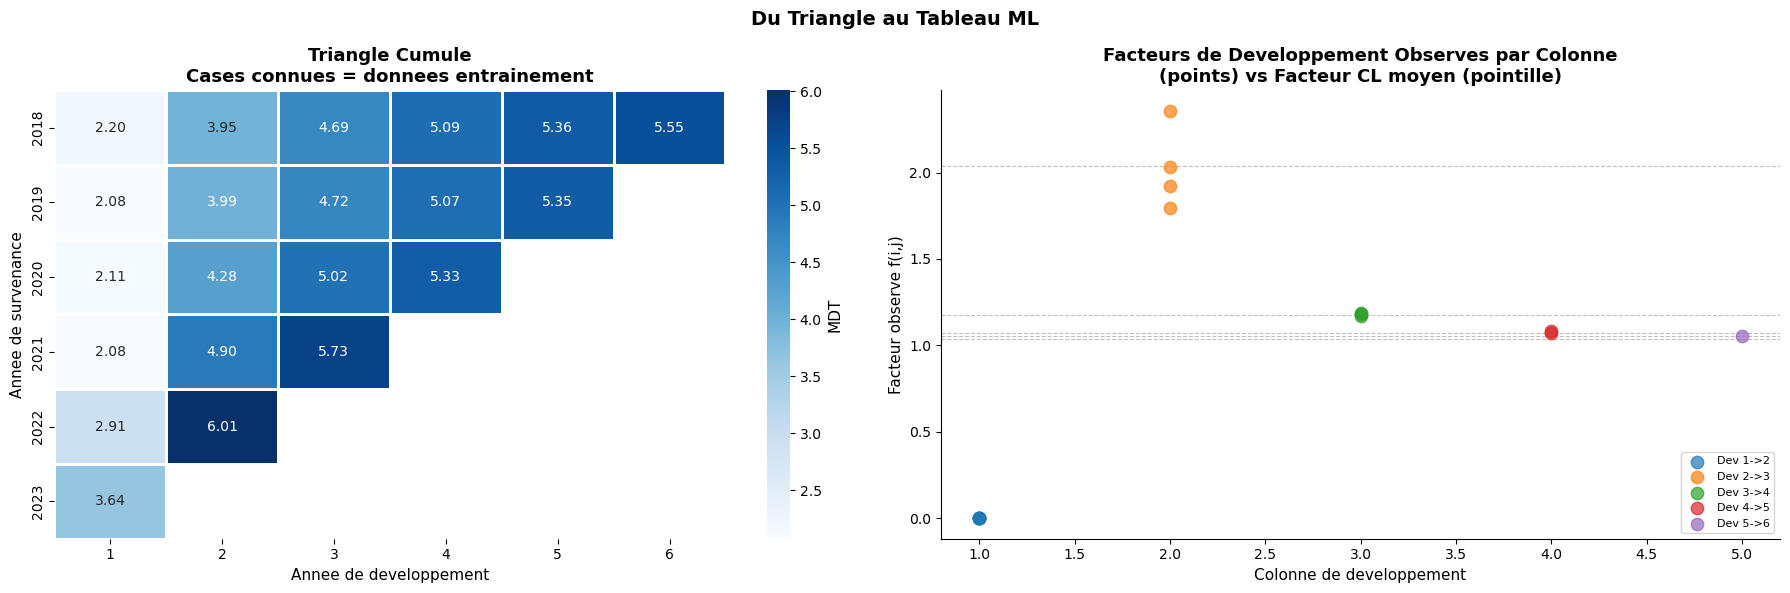

In [9]:
# Visualisation : triangle -> tableau ML
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Triangle cumule avec cases connues
mask = tri_cumul.isnull()
sns.heatmap(tri_cumul.fillna(0) / 1e6, annot=True, fmt='.2f', cmap='Blues',
            ax=axes[0], linewidths=0.8, annot_kws={'size': 10},
            cbar_kws={'label': 'MDT'}, mask=mask)
axes[0].set_title('Triangle Cumule\nCases connues = donnees entrainement', fontweight='bold')
axes[0].set_xlabel('Annee de developpement')
axes[0].set_ylabel('Annee de survenance')

# Distribution des facteurs observes par colonne
for k in range(len(devs)-1):
    dev = devs[k]
    dev_next = devs[k+1]
    data_col = df_ml[df_ml['dev_actuel'] == dev]['facteur_obs']
    if len(data_col) > 0:
        axes[1].scatter([k+1]*len(data_col), data_col, alpha=0.7, s=80,
                       label=f'Dev {dev}->{dev_next}', zorder=5)
        axes[1].axhline(facteurs_list[k], color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

axes[1].set_title('Facteurs de Developpement Observes par Colonne\n(points) vs Facteur CL moyen (pointille)', fontweight='bold')
axes[1].set_xlabel('Colonne de developpement')
axes[1].set_ylabel('Facteur observe f(i,j)')
axes[1].legend(fontsize=8)

plt.suptitle('Du Triangle au Tableau ML', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering

On enrichit les features de base avec des variables derivees
qui capturent des informations additionnelles sur le comportement de developpement.


In [10]:
# Features finales pour XGBoost
FEATURES = [
    # Position dans le triangle
    'annee_survenance', 'dev_actuel', 'dev_restant', 'anciennete',
    # Valeurs du triangle
    'C_cumul_actuel', 'C_precedent', 'facteur_obs', 'log_C_cumul',
    # Infos sinistres
    'nb_sinistres', 'pct_corporels', 'delai_decl_moyen', 'pct_ouverts',
    # Infos financieres
    'prime', 'sap_total', 'taux_sinistralite', 'facteur_cl_col',
]

TARGET = 'C_cumul_suivant'

X = df_ml[FEATURES]
y = df_ml[TARGET]

print(f"Features finales : {len(FEATURES)}")
for i, f in enumerate(FEATURES):
    print(f"  {i+1:2d}. {f}")

print(f"\nVariable cible : {TARGET}")
print(f"Observations   : {len(X)}")
print(f"\nStatistiques de la cible :")
print(y.describe().round(0))

Features finales : 16
   1. annee_survenance
   2. dev_actuel
   3. dev_restant
   4. anciennete
   5. C_cumul_actuel
   6. C_precedent
   7. facteur_obs
   8. log_C_cumul
   9. nb_sinistres
  10. pct_corporels
  11. delai_decl_moyen
  12. pct_ouverts
  13. prime
  14. sap_total
  15. taux_sinistralite
  16. facteur_cl_col

Variable cible : C_cumul_suivant
Observations   : 15

Statistiques de la cible :
count         15.0
mean     5001707.0
std       599999.0
min      3951727.0
25%      4703625.0
50%      5065568.0
75%      5352404.0
max      6011303.0
Name: C_cumul_suivant, dtype: float64


---
## 4. Validation Temporelle (Out-of-Time)

### Principe critique (Gabrielli & Wuthrich, 2018)

En ML Reserving, on ne peut PAS utiliser une validation croisee classique.  
On doit valider **dans le temps** pour eviter le data leakage :

- **Entrainement** : transitions des annees 2018, 2019, 2020 (matures)
- **Validation** : transitions des annees 2021, 2022 (recentes, moins de recul)
- **Prediction** : cases manquantes de 2022 et 2023 (inconnues)

Cette approche simule ce qu'un actuaire ferait en pratique.


In [11]:
# Split temporel
ANNEES_TRAIN = [2018, 2019, 2020]
ANNEES_VAL   = [2021, 2022]

mask_train = df_ml['annee_survenance'].isin(ANNEES_TRAIN)
mask_val   = df_ml['annee_survenance'].isin(ANNEES_VAL)

X_train = X[mask_train]
y_train = y[mask_train]
X_val   = X[mask_val]
y_val   = y[mask_val]

print("Split temporel out-of-time :")
print(f"  Entrainement (2018-2020) : {len(X_train)} transitions")
print(f"  Validation   (2021-2022) : {len(X_val)} transitions")
print()
print("Transitions par annee et developpement :")
print(df_ml.groupby(['annee_survenance', 'dev_actuel'])['C_cumul_suivant'].count().unstack())

Split temporel out-of-time :
  Entrainement (2018-2020) : 12 transitions
  Validation   (2021-2022) : 3 transitions

Transitions par annee et developpement :
dev_actuel          1    2    3    4    5
annee_survenance                         
2018              1.0  1.0  1.0  1.0  1.0
2019              1.0  1.0  1.0  1.0  NaN
2020              1.0  1.0  1.0  NaN  NaN
2021              1.0  1.0  NaN  NaN  NaN
2022              1.0  NaN  NaN  NaN  NaN


---
## 5. Modele XGBoost - Entrainement et Prediction

### Reference : Friedman (2001), Chen & Guestrin (2016)

XGBoost (eXtreme Gradient Boosting) est un algorithme d'ensemble qui construit
sequentiellement des arbres de decision, chacun corrigeant les erreurs du precedent.

Avantage par rapport a Chain-Ladder : il apprend des **facteurs de developpement personnalises**
par annee de survenance selon son profil (nb sinistres, % corporels, primes...).


In [12]:
# Entrainement XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)

# Predictions sur validation
y_pred_val = xgb_model.predict(X_val)

# Metriques sur validation
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae_xgb  = mean_absolute_error(y_val, y_pred_val)
r2_xgb   = r2_score(y_val, y_pred_val)

# Metriques Chain-Ladder sur validation (pour benchmark)
# CL predit C(i,j+1) = C(i,j) * f_j
y_pred_cl = X_val['C_cumul_actuel'] * X_val['facteur_cl_col']
rmse_cl   = np.sqrt(mean_squared_error(y_val, y_pred_cl))
mae_cl    = mean_absolute_error(y_val, y_pred_cl)
r2_cl     = r2_score(y_val, y_pred_cl)

print("Metriques sur validation (2021-2022) :")
print("-" * 50)
print(f"{'Metrique':<20} {'Chain-Ladder':>15} {'XGBoost':>15} {'Gain'}")
print("-" * 50)
print(f"{'RMSE (DT)':<20} {rmse_cl:>15,.0f} {rmse_xgb:>15,.0f} {(rmse_cl-rmse_xgb)/rmse_cl*100:>+.1f}%")
print(f"{'MAE (DT)':<20} {mae_cl:>15,.0f} {mae_xgb:>15,.0f} {(mae_cl-mae_xgb)/mae_cl*100:>+.1f}%")
print(f"{'R2':<20} {r2_cl:>15.3f} {r2_xgb:>15.3f} {r2_xgb-r2_cl:>+.3f}")
print("-" * 50)
print(f"\nInterpretation : XGBoost {'ameliore' if rmse_xgb < rmse_cl else 'ne ameliore pas'} Chain-Ladder")
print(f"sur les annees recentes (2021-2022) selon le RMSE.")

Metriques sur validation (2021-2022) :
--------------------------------------------------
Metrique                Chain-Ladder         XGBoost Gain
--------------------------------------------------
RMSE (DT)                    391,872       1,178,839 -200.8%
MAE (DT)                     266,363       1,065,726 -300.1%
R2                             0.311          -5.231 -5.543
--------------------------------------------------

Interpretation : XGBoost ne ameliore pas Chain-Ladder
sur les annees recentes (2021-2022) selon le RMSE.


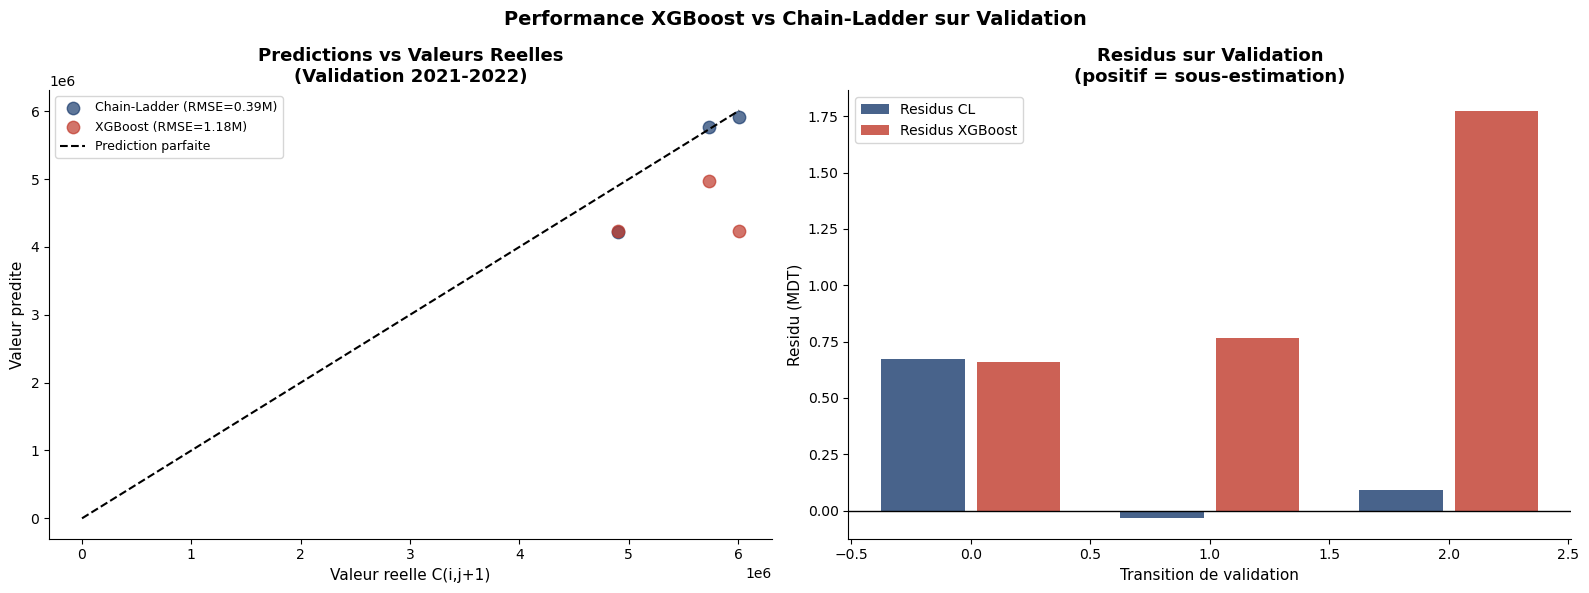

In [13]:
# Visualisation predictions vs valeurs reelles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(y_val, y_pred_cl, alpha=0.7, color=C1, s=80, label=f'Chain-Ladder (RMSE={rmse_cl/1e6:.2f}M)')
axes[0].scatter(y_val, y_pred_val, alpha=0.7, color=C3, s=80, label=f'XGBoost (RMSE={rmse_xgb/1e6:.2f}M)')
max_val = max(y_val.max(), y_pred_val.max(), y_pred_cl.max())
axes[0].plot([0, max_val], [0, max_val], 'k--', linewidth=1.5, label='Prediction parfaite')
axes[0].set_xlabel('Valeur reelle C(i,j+1)')
axes[0].set_ylabel('Valeur predite')
axes[0].set_title('Predictions vs Valeurs Reelles\n(Validation 2021-2022)', fontweight='bold')
axes[0].legend(fontsize=9)

# Residus
residus_cl  = y_val.values - y_pred_cl.values
residus_xgb = y_val.values - y_pred_val
x_pos = range(len(y_val))
axes[1].bar([p - 0.2 for p in x_pos], residus_cl / 1e6,  0.35, label='Residus CL',      color=C1, alpha=0.8)
axes[1].bar([p + 0.2 for p in x_pos], residus_xgb / 1e6, 0.35, label='Residus XGBoost', color=C3, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Transition de validation')
axes[1].set_ylabel('Residu (MDT)')
axes[1].set_title('Residus sur Validation\n(positif = sous-estimation)', fontweight='bold')
axes[1].legend()

plt.suptitle('Performance XGBoost vs Chain-Ladder sur Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Prediction des cases manquantes du triangle
# On construit le tableau des cases a predire
rows_pred = []
for i, annee_surv in enumerate(ANNEES):
    dev_max = N - i
    info    = infos_annee[annee_surv]

    for k, dev in enumerate(devs[:-1]):
        dev_next  = devs[k + 1]
        c_actuel  = tri_cumul.loc[annee_surv, dev]
        c_suivant = tri_cumul.loc[annee_surv, dev_next]

        if not pd.isna(c_actuel) and pd.isna(c_suivant):
            c_precedent = tri_cumul.loc[annee_surv, devs[k-1]] if k > 0 else 0
            facteur_obs = c_actuel / c_precedent if (c_precedent and c_precedent > 0) else 0

            rows_pred.append({
                'annee_survenance': annee_surv,
                'dev_actuel':       dev,
                'dev_suivant':      dev_next,
                'dev_restant':      len(devs) - 1 - k,
                'anciennete':       2023 - annee_surv,
                'C_cumul_actuel':   c_actuel,
                'C_precedent':      c_precedent,
                'facteur_obs':      facteur_obs,
                'log_C_cumul':      np.log1p(c_actuel),
                'nb_sinistres':     info['nb_sinistres'],
                'pct_corporels':    info['pct_corporels'],
                'delai_decl_moyen': info['delai_decl_moyen'],
                'pct_ouverts':      info['pct_ouverts'],
                'prime':            info['prime'],
                'sap_total':        info['sap_total'],
                'taux_sinistralite':c_actuel / info['prime'] if info['prime'] > 0 else 0,
                'facteur_cl_col':   facteurs_list[k] if k < len(facteurs_list) else 1.0,
            })

df_pred = pd.DataFrame(rows_pred)

if len(df_pred) > 0:
    pred_xgb = xgb_model.predict(df_pred[FEATURES])
    df_pred['C_predit_XGB'] = pred_xgb

    # Remplir le triangle predit
    tri_xgb = tri_cumul.copy()
    for _, row in df_pred.iterrows():
        tri_xgb.loc[row['annee_survenance'], row['dev_suivant']] = row['C_predit_XGB']

    # Propager les predictions suivantes
    for i, annee_surv in enumerate(ANNEES):
        for k, dev in enumerate(devs):
            if pd.isna(tri_xgb.loc[annee_surv, dev]):
                if k > 0 and not pd.isna(tri_xgb.loc[annee_surv, devs[k-1]]):
                    prev = tri_xgb.loc[annee_surv, devs[k-1]]
                    tri_xgb.loc[annee_surv, dev] = prev * facteurs_list[k-1]

    print("Triangle predit par XGBoost :")
    display(tri_xgb.round(0).astype(int))
else:
    print("Toutes les cases sont deja connues - triangle complet")
    tri_xgb = tri_cumul.copy()

Triangle predit par XGBoost :


,1,2,3,4,5,6
2018,2199765,3951727,4689648,5086513,5358377,5545551
2019,2075632,3993845,4717602,5065568,5346432,5482188
2020,2107584,4280970,5016023,5331244,5380722,5568676
2021,2077306,4899350,5731455,5312182,5601403,5797065
2022,2907693,6011303,5083203,5456798,5753892,5954881
2023,3637932,4235663,4984770,5351131,5642471,5839569


---
## 6. Intervalles de Confiance par Bootstrap

### Reference : England & Verrall (2002)

Le Bootstrap permet de quantifier l'incertitude des predictions XGBoost,
similairement a la methode Mack pour Chain-Ladder.

On realise N_BOOT rééchantillonnages du tableau d'entrainement,
on reentraine un modele sur chaque echantillon, et on obtient
une distribution empirique des reserves estimees.


Bootstrap 500 iterations termine

Distribution Bootstrap des reserves XGBoost :
  Moyenne   :    2,134,557 DT
  Mediane   :    2,160,871 DT
  Std       :      462,833 DT
  IC 90%    : [   1,297,828 ;    2,790,785] DT
  IC 95%    : [   1,103,566 ;    2,875,378] DT


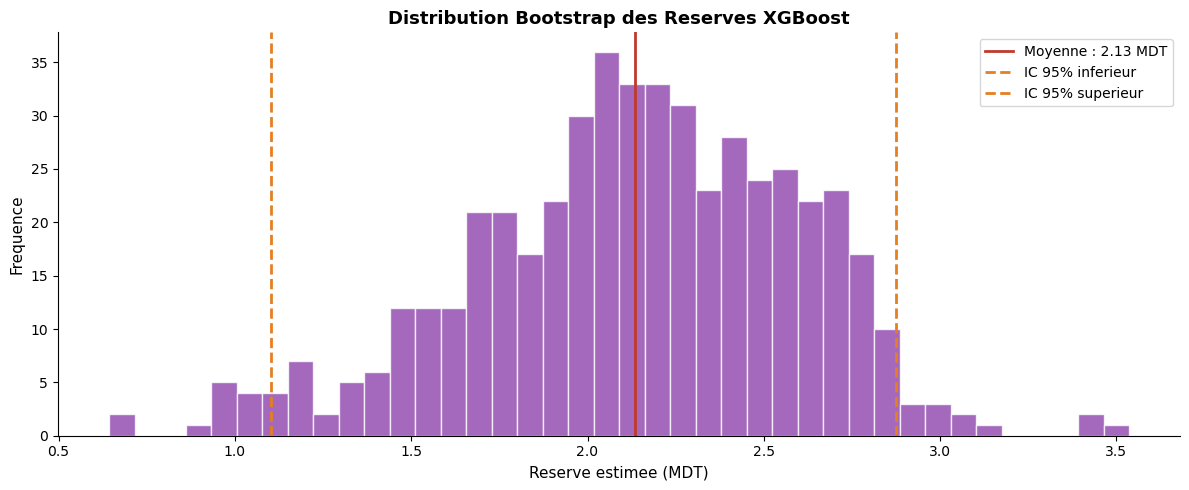

In [15]:
N_BOOT = 500
np.random.seed(RANDOM_STATE)

reserves_boot = []
ibnr_boot_par_annee = {a: [] for a in ANNEES}

for b in range(N_BOOT):
    # Rééchantillonnage avec remplacement
    idx_boot  = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_b       = X_train.iloc[idx_boot]
    y_b       = y_train.iloc[idx_boot]

    # Reentrainement
    model_b = xgb.XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.8, random_state=b, verbosity=0
    )
    model_b.fit(X_b, y_b, verbose=False)

    # Prediction et calcul reserve totale
    if len(df_pred) > 0:
        pred_b = model_b.predict(df_pred[FEATURES])
        tri_b  = tri_cumul.copy()
        for j_idx, row in enumerate(df_pred.itertuples()):
            tri_b.loc[row.annee_survenance, row.dev_suivant] = pred_b[j_idx]
        for i, annee_surv in enumerate(ANNEES):
            for k, dev in enumerate(devs):
                if pd.isna(tri_b.loc[annee_surv, dev]):
                    if k > 0 and not pd.isna(tri_b.loc[annee_surv, devs[k-1]]):
                        tri_b.loc[annee_surv, dev] = tri_b.loc[annee_surv, devs[k-1]] * facteurs_list[k-1]
        reserve_b = sum(
            tri_b.loc[a, devs[-1]] - tri_cumul.loc[a, N - (a - 2018)]
            for a in ANNEES
        )
        reserves_boot.append(reserve_b)

if reserves_boot:
    reserves_boot = np.array(reserves_boot)
    print(f"Bootstrap {N_BOOT} iterations termine")
    print(f"\nDistribution Bootstrap des reserves XGBoost :")
    print(f"  Moyenne   : {reserves_boot.mean():>12,.0f} DT")
    print(f"  Mediane   : {np.median(reserves_boot):>12,.0f} DT")
    print(f"  Std       : {reserves_boot.std():>12,.0f} DT")
    print(f"  IC 90%    : [{np.percentile(reserves_boot,5):>12,.0f} ; {np.percentile(reserves_boot,95):>12,.0f}] DT")
    print(f"  IC 95%    : [{np.percentile(reserves_boot,2.5):>12,.0f} ; {np.percentile(reserves_boot,97.5):>12,.0f}] DT")

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(reserves_boot / 1e6, bins=40, color=C5, alpha=0.8, edgecolor='white')
    ax.axvline(reserves_boot.mean() / 1e6, color=C3, linewidth=2, label=f'Moyenne : {reserves_boot.mean()/1e6:.2f} MDT')
    ax.axvline(np.percentile(reserves_boot, 2.5) / 1e6, color=C4, linewidth=2, linestyle='--', label='IC 95% inferieur')
    ax.axvline(np.percentile(reserves_boot, 97.5) / 1e6, color=C4, linewidth=2, linestyle='--', label='IC 95% superieur')
    ax.set_xlabel('Reserve estimee (MDT)')
    ax.set_ylabel('Frequence')
    ax.set_title('Distribution Bootstrap des Reserves XGBoost', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Pas assez de cases manquantes pour le Bootstrap")
    reserves_boot = np.array([0])

---
## 7. SHAP - Explicabilite des Predictions

### Reference : Lundberg & Lee (2017), Shapley (1953)

SHAP (SHapley Additive exPlanations) decompose chaque prediction en contributions
individuelles de chaque feature, rendant les predictions XGBoost interpretables
pour les equipes actuarielles.


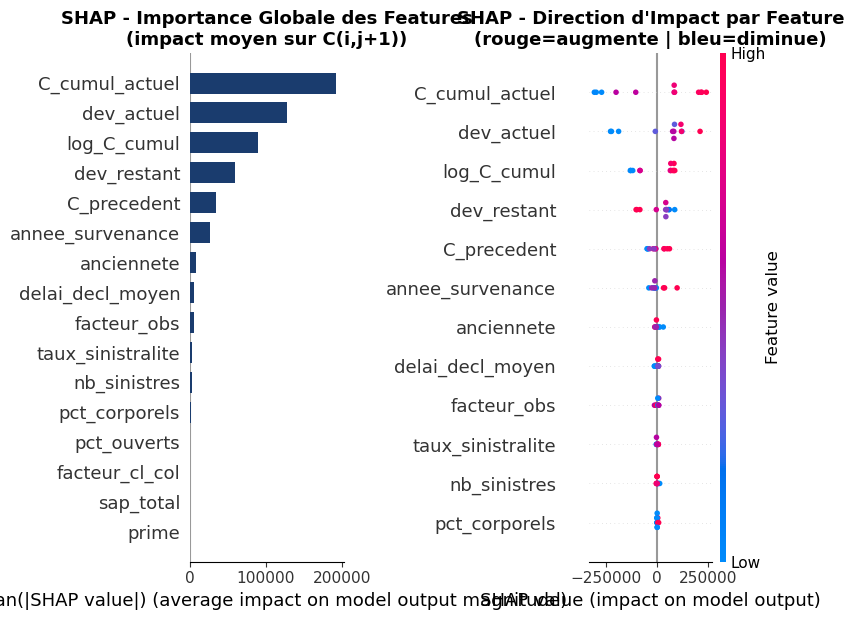

Interpretation SHAP :
  La taille des barres indique l'importance de chaque feature
  sur la prediction du montant cumule suivant C(i,j+1)


In [16]:
# SHAP sur le modèle XGBoost entraîné
explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer(X_train)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# SHAP Summary Plot - importance globale
plt.sca(axes[0])
shap.summary_plot(shap_vals, X_train, plot_type='bar',
                  show=False, color=C1, max_display=16)
axes[0].set_title('SHAP - Importance Globale des Features\n(impact moyen sur C(i,j+1))', fontweight='bold')

# SHAP Summary Plot - direction d'impact
plt.sca(axes[1])
shap.summary_plot(shap_vals, X_train, show=False, max_display=12)
axes[1].set_title("SHAP - Direction d'Impact par Feature\n(rouge=augmente | bleu=diminue)", fontweight='bold')

plt.tight_layout()
plt.savefig('shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

print("Interpretation SHAP :")
print("  La taille des barres indique l'importance de chaque feature")
print("  sur la prediction du montant cumule suivant C(i,j+1)")

Exemple d'explication individuelle - Transition 1 de la validation :
  Annee survenance : 2021
  Dev actuel       : 1
  C cumul actuel   : 2,077,306 DT
  Valeur reelle    : 4,899,350 DT
  Pred XGBoost     : 4,241,972 DT
  Pred CL          : 4,227,930 DT


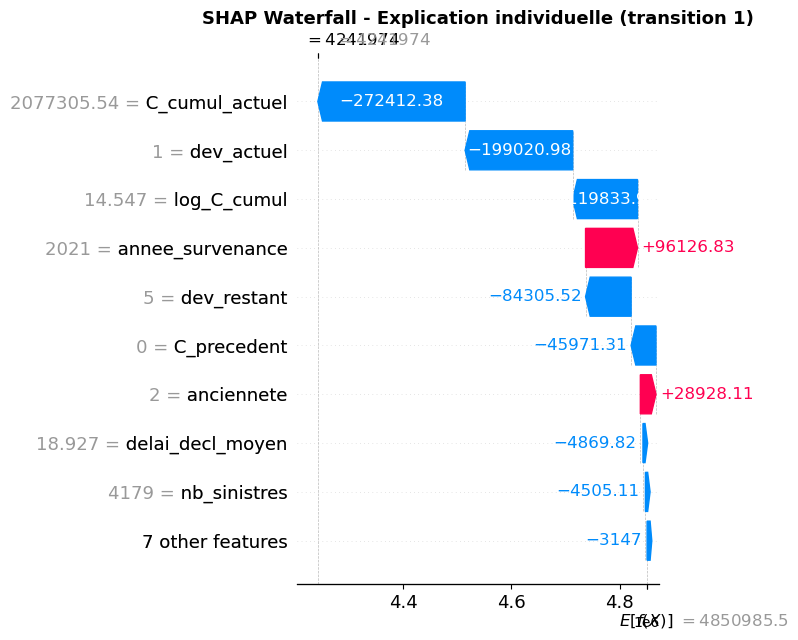

In [17]:
# SHAP Waterfall - explication individuelle
# Montrer pourquoi XGBoost a predit ce montant pour la transition la plus recente
if len(X_val) > 0:
    idx_exemple = 0
    print(f"Exemple d'explication individuelle - Transition {idx_exemple + 1} de la validation :")
    print(f"  Annee survenance : {X_val.iloc[idx_exemple]['annee_survenance']:.0f}")
    print(f"  Dev actuel       : {X_val.iloc[idx_exemple]['dev_actuel']:.0f}")
    print(f"  C cumul actuel   : {X_val.iloc[idx_exemple]['C_cumul_actuel']:,.0f} DT")
    print(f"  Valeur reelle    : {y_val.iloc[idx_exemple]:,.0f} DT")
    print(f"  Pred XGBoost     : {y_pred_val[idx_exemple]:,.0f} DT")
    print(f"  Pred CL          : {y_pred_cl.values[idx_exemple]:,.0f} DT")

    fig, ax = plt.subplots(figsize=(12, 6))
    shap_vals_val = explainer(X_val)
    shap.waterfall_plot(shap_vals_val[idx_exemple], show=False, max_display=10)
    plt.title(f'SHAP Waterfall - Explication individuelle (transition {idx_exemple+1})', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 8. Benchmark XGBoost vs Chain-Ladder vs BF vs Cape Cod

Comparaison complete des quatre methodes sur :
- Les reserves estimees par annee de survenance
- Les intervalles de confiance
- Les metriques de precision sur la validation


In [18]:
# Recalcul reserves Partie 1 pour benchmark
# Chain-Ladder
tri_cl = tri_cumul.copy()
for i, annee_surv in enumerate(ANNEES):
    for k, dev in enumerate(devs):
        if pd.isna(tri_cl.loc[annee_surv, dev]):
            if k > 0 and not pd.isna(tri_cl.loc[annee_surv, devs[k-1]]):
                tri_cl.loc[annee_surv, dev] = tri_cl.loc[annee_surv, devs[k-1]] * facteurs_list[k-1]

ibnr_cl = {a: tri_cl.loc[a, devs[-1]] - tri_cumul.loc[a, N-(a-2018)] for a in ANNEES}

# BF
proportions = {}
for i, annee_surv in enumerate(ANNEES):
    futurs = facteurs_list[N-i-1:]
    produit = 1.0
    for f in futurs:
        produit *= f
    proportions[annee_surv] = 1.0/produit if produit > 0 else 1.0

annees_matures = [2018, 2019, 2020]
taux_apriori   = np.mean([
    (tri_cumul.loc[a, N-(a-2018)] / proportions[a]) / primes[a]
    for a in annees_matures if primes.get(a,0) > 0
])
ibnr_bf = {a: (1 - proportions[a]) * primes.get(a,0) * taux_apriori for a in ANNEES}

# Cape Cod
num = sum(tri_cumul.loc[a, N-(a-2018)] for a in ANNEES)
den = sum(primes.get(a,0) * proportions[a] for a in ANNEES)
rho = num / den if den > 0 else 0
ibnr_cc = {a: (1-proportions[a]) * rho * primes.get(a,0) for a in ANNEES}

# XGBoost
ibnr_xgb = {}
for a in ANNEES:
    if len(df_pred) > 0:
        ibnr_xgb[a] = tri_xgb.loc[a, devs[-1]] - tri_cumul.loc[a, N-(a-2018)]
    else:
        ibnr_xgb[a] = ibnr_cl[a]

# Tableau comparatif complet
bench = pd.DataFrame({
    'Chain-Ladder (DT)': ibnr_cl,
    'BF (DT)':           ibnr_bf,
    'Cape Cod (DT)':     ibnr_cc,
    'XGBoost ML (DT)':   ibnr_xgb,
    'SAP 2023 Cie (DT)': sap_par_annee,
})
bench.index.name = 'Annee'
bench.loc['TOTAL'] = bench.sum()

print("Benchmark complet - Toutes methodes :")
display(bench.round(0))

Benchmark complet - Toutes methodes :


,Chain-Ladder (DT),BF (DT),Cape Cod (DT),XGBoost ML (DT),SAP 2023 Cie (DT)
Annee,,,,,
2018,0.0,0.0,0.0,0.0,526076.0
2019,186756.0,185874.0,184032.0,135757.0,604875.0
2020,486623.0,511912.0,506838.0,237432.0,1216725.0
2021,982841.0,1072072.0,1061446.0,65611.0,2479054.0
2022,2276282.0,2316728.0,2293764.0,-56422.0,4050536.0
2023,6570083.0,5982204.0,5922908.0,2201637.0,6766834.0
TOTAL,10502586.0,10068789.0,9968987.0,2584015.0,15644100.0


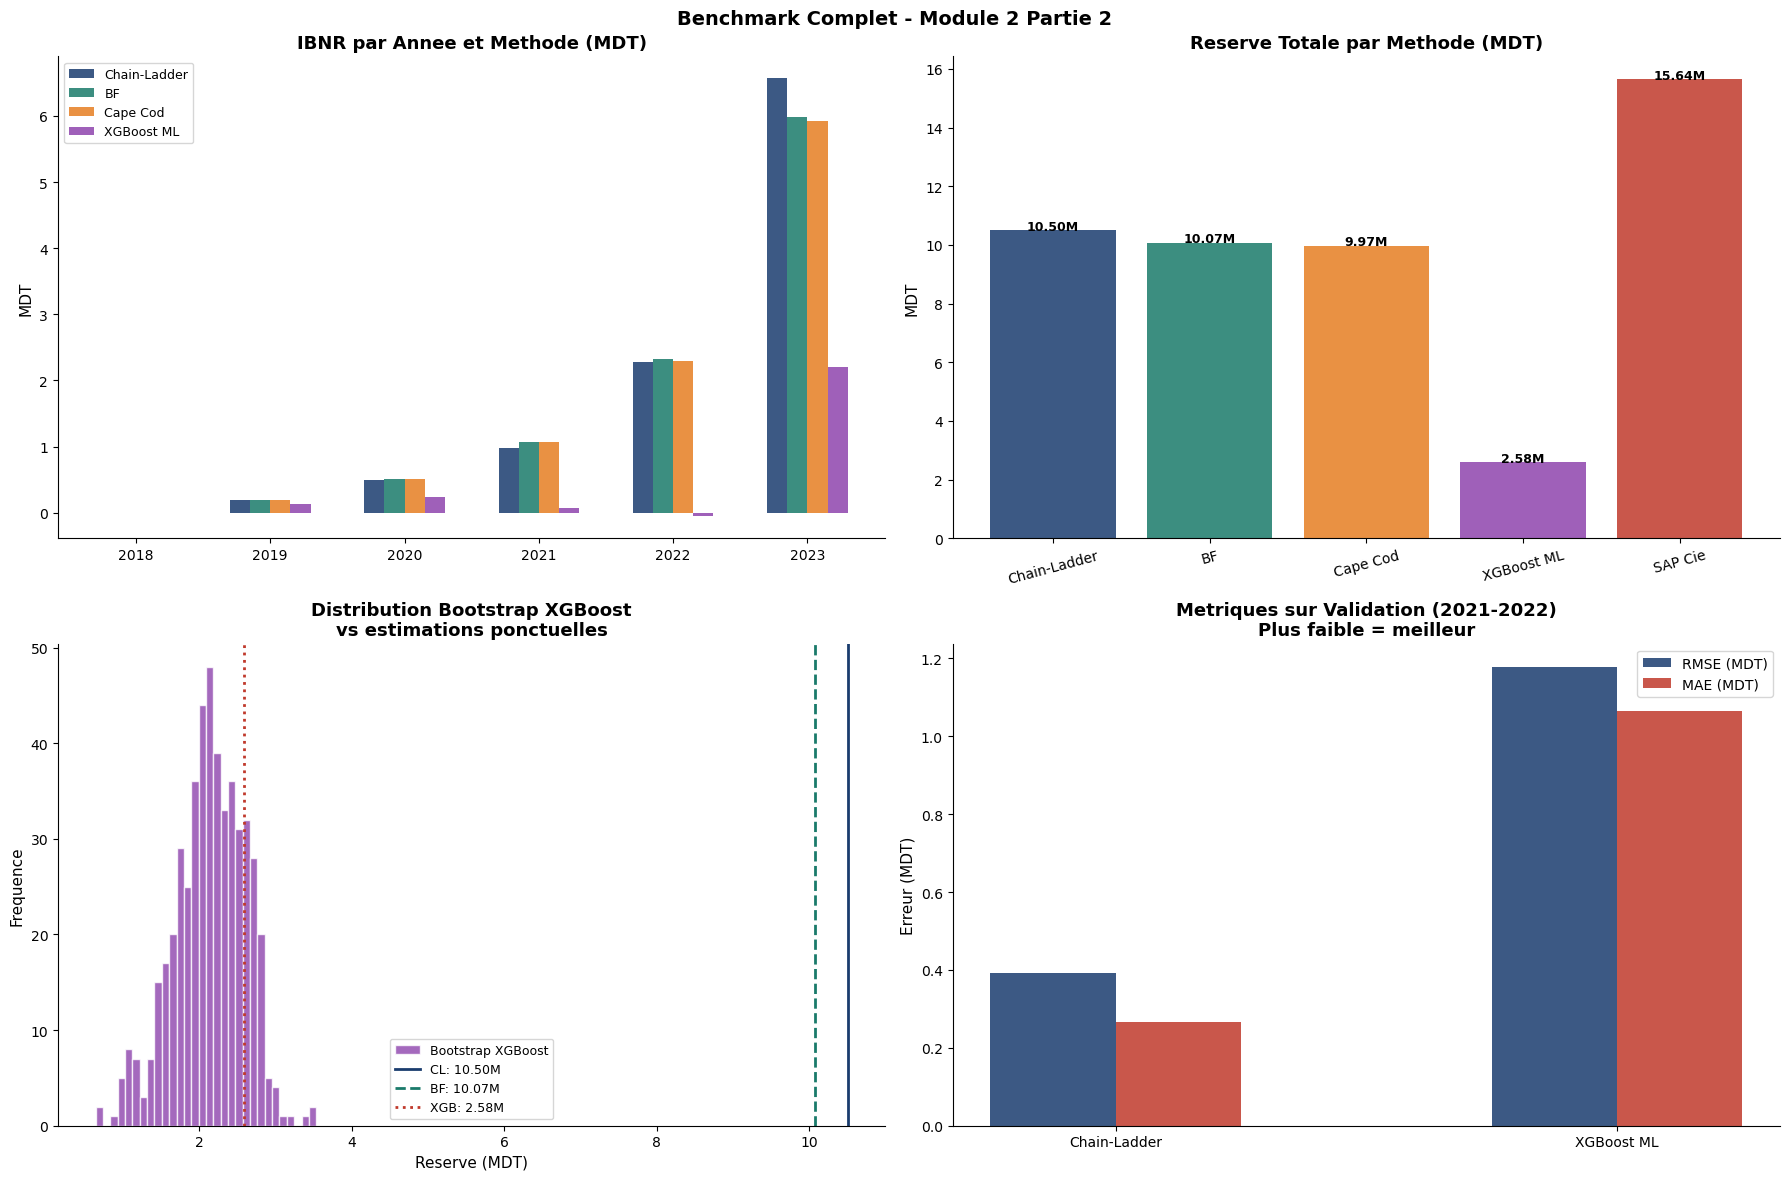

In [19]:
# Visualisation benchmark finale
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Barplot par annee et methode
x  = np.arange(len(ANNEES))
w  = 0.15
ax = axes[0][0]
ax.bar(x - 1.5*w, [ibnr_cl[a]/1e6  for a in ANNEES], w, label='Chain-Ladder', color=C1, alpha=0.85)
ax.bar(x - 0.5*w, [ibnr_bf[a]/1e6  for a in ANNEES], w, label='BF',           color=C2, alpha=0.85)
ax.bar(x + 0.5*w, [ibnr_cc[a]/1e6  for a in ANNEES], w, label='Cape Cod',     color=C4, alpha=0.85)
ax.bar(x + 1.5*w, [ibnr_xgb[a]/1e6 for a in ANNEES], w, label='XGBoost ML',  color=C5, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ANNEES)
ax.set_title('IBNR par Annee et Methode (MDT)', fontweight='bold')
ax.set_ylabel('MDT')
ax.legend(fontsize=9)

# Totaux
ax = axes[0][1]
totaux = {
    'Chain-Ladder':  sum(ibnr_cl.values()),
    'BF':            sum(ibnr_bf.values()),
    'Cape Cod':      sum(ibnr_cc.values()),
    'XGBoost ML':    sum(ibnr_xgb.values()),
    'SAP Cie':       sum(sap_par_annee.values()),
}
colors_tot = [C1, C2, C4, C5, C3]
bars = ax.bar(totaux.keys(), [v/1e6 for v in totaux.values()], color=colors_tot, alpha=0.85)
ax.set_title('Reserve Totale par Methode (MDT)', fontweight='bold')
ax.set_ylabel('MDT')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, totaux.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val/1e6 + 0.02,
            f'{val/1e6:.2f}M', ha='center', fontsize=9, fontweight='bold')

# Distribution Bootstrap
ax = axes[1][0]
if len(reserves_boot) > 1:
    ax.hist(reserves_boot/1e6, bins=30, color=C5, alpha=0.8, edgecolor='white', label='Bootstrap XGBoost')
    ax.axvline(sum(ibnr_cl.values())/1e6,  color=C1, linewidth=2, linestyle='-',  label=f'CL: {sum(ibnr_cl.values())/1e6:.2f}M')
    ax.axvline(sum(ibnr_bf.values())/1e6,  color=C2, linewidth=2, linestyle='--', label=f'BF: {sum(ibnr_bf.values())/1e6:.2f}M')
    ax.axvline(sum(ibnr_xgb.values())/1e6, color=C3, linewidth=2, linestyle=':',  label=f'XGB: {sum(ibnr_xgb.values())/1e6:.2f}M')
    ax.set_xlabel('Reserve (MDT)')
    ax.set_ylabel('Frequence')
    ax.set_title('Distribution Bootstrap XGBoost\nvs estimations ponctuelles', fontweight='bold')
    ax.legend(fontsize=9)

# Metriques comparatives
ax = axes[1][1]
metriques = pd.DataFrame({
    'RMSE (MDT)':   [rmse_cl/1e6,  rmse_xgb/1e6],
    'MAE (MDT)':    [mae_cl/1e6,   mae_xgb/1e6],
    'R2':           [r2_cl,        r2_xgb],
}, index=['Chain-Ladder', 'XGBoost ML'])

x_met = np.arange(2)
w_met = 0.25
ax.bar(x_met - w_met/2, metriques['RMSE (MDT)'], w_met, label='RMSE (MDT)', color=C1, alpha=0.85)
ax.bar(x_met + w_met/2, metriques['MAE (MDT)'],  w_met, label='MAE (MDT)',  color=C3, alpha=0.85)
ax.set_xticks(x_met)
ax.set_xticklabels(['Chain-Ladder', 'XGBoost ML'])
ax.set_title('Metriques sur Validation (2021-2022)\nPlus faible = meilleur', fontweight='bold')
ax.set_ylabel('Erreur (MDT)')
ax.legend()

plt.suptitle('Benchmark Complet - Module 2 Partie 2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Synthese et Recommandation Finale

In [20]:
# Synthese finale
total_cl  = sum(ibnr_cl.values())
total_bf  = sum(ibnr_bf.values())
total_cc  = sum(ibnr_cc.values())
total_xgb = sum(ibnr_xgb.values())
total_sap = sum(sap_par_annee.values())
ic_95_low = np.percentile(reserves_boot, 2.5) if len(reserves_boot) > 1 else total_xgb
ic_95_high= np.percentile(reserves_boot, 97.5) if len(reserves_boot) > 1 else total_xgb

print("=" * 65)
print("  SYNTHESE MODULE 2 - PARTIE 1 + PARTIE 2")
print("=" * 65)
print(f"  SAP 2023 compagnie        : {total_sap:>14,.0f} DT")
print(f"  Reserve Chain-Ladder      : {total_cl:>14,.0f} DT")
print(f"  Reserve BF                : {total_bf:>14,.0f} DT")
print(f"  Reserve Cape Cod          : {total_cc:>14,.0f} DT")
print(f"  Reserve XGBoost ML        : {total_xgb:>14,.0f} DT")
print(f"  IC 95% Bootstrap          : [{ic_95_low:>12,.0f} ; {ic_95_high:>12,.0f}] DT")
print()
print(f"  Performance sur validation :")
print(f"    RMSE Chain-Ladder : {rmse_cl:>12,.0f} DT")
print(f"    RMSE XGBoost      : {rmse_xgb:>12,.0f} DT")
amelioration = (rmse_cl - rmse_xgb) / rmse_cl * 100
print(f"    Gain ML           : {amelioration:>+11.1f}%")
print()
if rmse_xgb < rmse_cl:
    print("  CONCLUSION : XGBoost ameliore Chain-Ladder sur ce portefeuille.")
    print("  Recommandation : utiliser XGBoost comme methode complementaire")
    print("  avec Bootstrap pour les intervalles de confiance.")
else:
    print("  CONCLUSION : Chain-Ladder reste plus performant sur ce portefeuille.")
    print("  Recommandation : conserver CL comme methode principale.")
    print("  XGBoost peut servir comme second avis sur les annees jeunes.")
print()
print("  LIVRABLES POUR LES MODULES SUIVANTS :")
print("  -> Module 4 : reserve centrale pour prevision ratio combine")
print("  -> Module 5 : dashboard Power BI - comparaison CL vs XGBoost")

  SYNTHESE MODULE 2 - PARTIE 1 + PARTIE 2
  SAP 2023 compagnie        :     15,644,100 DT
  Reserve Chain-Ladder      :     10,502,586 DT
  Reserve BF                :     10,068,789 DT
  Reserve Cape Cod          :      9,968,987 DT
  Reserve XGBoost ML        :      2,584,015 DT
  IC 95% Bootstrap          : [   1,103,566 ;    2,875,378] DT

  Performance sur validation :
    RMSE Chain-Ladder :      391,872 DT
    RMSE XGBoost      :    1,178,839 DT
    Gain ML           :      -200.8%

  CONCLUSION : Chain-Ladder reste plus performant sur ce portefeuille.
  Recommandation : conserver CL comme methode principale.
  XGBoost peut servir comme second avis sur les annees jeunes.

  LIVRABLES POUR LES MODULES SUIVANTS :
  -> Module 4 : reserve centrale pour prevision ratio combine
  -> Module 5 : dashboard Power BI - comparaison CL vs XGBoost


In [21]:
# ── Sauvegarde modèle XGBoost Reserving ──────────────────────────────
import joblib, os

os.makedirs('models', exist_ok=True)

joblib.dump(xgb_model, 'models/xgb_reserving.pkl')
print('✅ models/xgb_reserving.pkl sauvegardé')

# Téléchargement
try:
    from IPython.display import FileLink, display
    display(FileLink('models/xgb_reserving.pkl'))
except:
    print('→ Télécharge depuis : models/xgb_reserving.pkl')

✅ models/xgb_reserving.pkl sauvegardé


c:\Users\LENOVO\Desktop\Actuariat\NotebookPrevision\models\xgb_reserving.pkl